In [32]:
import numpy as np
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math

In [33]:
def add250_coeff(P, P250):
    P[1] = P250[0]
    P[2] = P250[1]
    P[5] = P250[2]
    return P

In [34]:
def pacejka(P, L, IA, alpha, FZ):
    #P = [250, 1.4, 2.4, -0.25, 3, -0.1, -1.5, 0, 0, -30.5, 1.15, 1, 0, 0, -0.128, 0, 0, 0, 1.43];
    #L = [1, 1, 1, 1, 1, 1, 1, 1];
    dfz = (FZ - P[0]) / P[0]
    Svy = FZ * (P[15] + P[16] * dfz + (P[17] + P[18] * dfz) * IA) * L[7] * L[4]
    Ey = (P[5] + P[6] * dfz) * (1 - (P[7] + P[8] * IA) * np.sign(alpha)) * L[6]
    Shy = (P[12] + P[13] * dfz + P[14] * IA) * L[5]
    alphaY = alpha + Shy
    Cy = P[1] * L[1]
    Dy = FZ * (P[2] + P[3] * dfz) * (1 - P[4] * IA**2) * L[0]
    x1 = 2 * np.arctan(FZ / (P[10] * P[0] * L[2]))
    x2 = P[9] * P[0] * np.sin(x1) * (1 - P[11] * np.abs(IA)) * L[3] * L[4]
    By = x2 / (Cy * Dy)

    x3 = By * alphaY
    FY = Dy * np.sin(Cy * np.arctan(x3 - Ey * (x3 - np.arctan(x3)))) + Svy

    return FY

def pacejka250(P250):
    dfz = (FZ250 - P[0]) / P[0]
    Svy = FZ250 * (P[15] + P[16] * dfz + (P[17] + P[18] * dfz) * IA250) * L[7] * L[4]
    Ey = (P250[2] + P[6] * dfz) * (1 - (P[7] + P[8] * IA250) * np.sign(alpha250)) * L[6]
    Shy = (0 + P[13] * dfz + P[14] * IA250) * L[5]
    alphaY = alpha250 + Shy
    Cy = P250[0] * L[1]
    Dy = FZ250 * (P250[1] + P[3] * dfz) * (1 - P[4] * IA250**2) * L[0]
    x1 = 2 * np.arctan(FZ250 / (P[10] * P[0] * L[2]))
    x2 = P[9] * P[0] * np.sin(x1) * (1 - P[11] * np.abs(IA250)) * L[3] * L[4]
    By = x2 / (Cy * Dy)
    x3 = By * alphaY
    FY_calculated = Dy * np.sin(Cy * np.arctan(x3 - Ey * (x3 - np.arctan(x3)))) + Svy
    return rmse(FY_measured250, FY_calculated)

def rmse(FY_measured, FY_calculated):
    #calculate rmse_value
    sumDifference = 0
    n = len(FY_measured)
    for i in range(n):
        sumDifference += (FY_measured[i] - FY_calculated[i])**2
    radicand = sumDifference/n
    rmse_value = math.sqrt(radicand)
    return rmse_value

def remove_small_data(P):
    for i in range(len(P)):
        if abs(P[i]) < 1e-10:
            P[i] = 0

#graph the resulting data to see how it matches up
def graphResult(P, L, IA, alpha, FZ, FY_measured):
    #calculate FY
    FY_calculated = pacejka(P, L, IA, alpha, FZ)
    smoothed_measured = sm.nonparametric.lowess(FY_measured, alpha, frac=.1)
    smoothed_calculated = sm.nonparametric.lowess(FY_calculated, alpha, frac=.1)
    plt.plot(smoothed_measured[:, 0], smoothed_measured[:, 1], color='blue', linewidth=2, label='Measured')
    plt.plot(smoothed_calculated[:, 0], smoothed_calculated[:, 1], color='red', linewidth=2, label='Calculated')
    plt.show()

-565.3945236797618


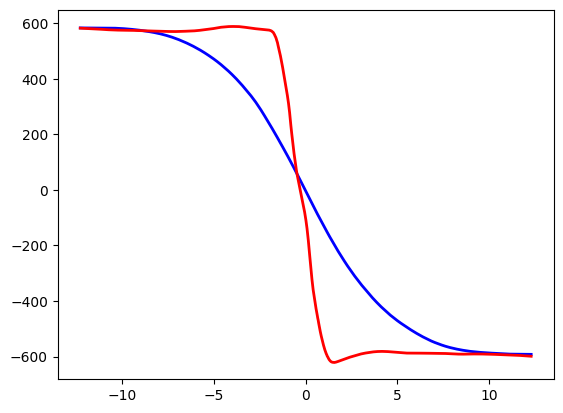

Parameters recieved: [250, -0.9689525596733786, 1.5266744240949706, -0.25, 3, 7.0, -1.5, 0, 0, -30.5, 1.15, 1, 0, 0, -0.128, 0, 0, 0, 1.43]


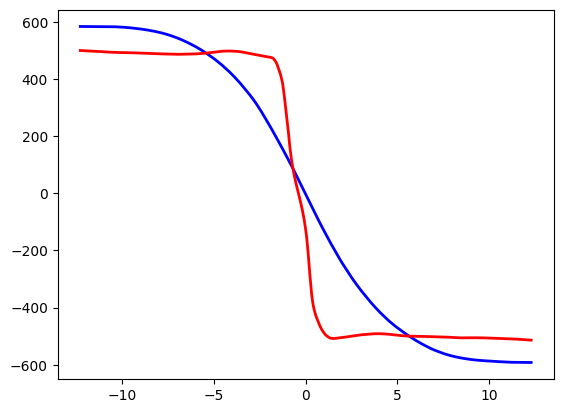

In [87]:
# Define the search space - range of values for each parameter
P = [250, 1.4, 2.4, -0.25, 3, -0.1, -1.5, 0, 0, -30.5, 1.15, 1, 0, 0, -0.128, 0, 0, 0, 1.43]


space250 = [Real(-6.0, 6.0, name='p1'), 
         Real(-6.0, 6.0, name='p2'), 
         Real(-6.0, 7.0, name='p5')]

#0.0001, 5.0
#-5.0, -0.00001
df250 = pd.read_csv("C:/Users/ajsau/Downloads/R20_FZ_250_filtered.csv")
L = np.array([1, 1, 1, 1, 1, 1, 1, 1])
FZ250 = df250["NormalForce"]
IA250 = df250["InclinationAngle"]
alpha250 = df250["SlipAngle"]
alpha250 = alpha250 * math.pi/180
FY_measured250 = df250["LateralForce"]
print(f"{pacejka(P, L, 0, 0.5, 250)}")

graphResult(P, L, IA250, alpha250*180/math.pi, FZ250, FY_measured250)
result = gp_minimize(pacejka250,      # The function to minimize
                     space250,                   # The search space
                     n_calls=50,              # The number of evaluations
                     random_state=42)
P = add250_coeff(P, result.x)
print(f"Parameters recieved: {P}")
# Plot convergence
graphResult(P, L, IA250, alpha250*180/math.pi, FZ250, FY_measured250)

#data is in degrees, formula wants radians